## CIS 508 Final Project

### Importing Libraries

In [1]:
# Core
import pandas as pd
import numpy as np
from pathlib import Path

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Model evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Neural network regressor
from sklearn.neural_network import MLPRegressor

# XGBoost
from xgboost import XGBRegressor

# Model saving
import joblib

# Plotting (for residual plots / confusion-matrix style visuals)
import matplotlib.pyplot as plt
import seaborn as sns

# Misc
import warnings
warnings.filterwarnings("ignore")

### Data Inspection

#### Importing Data

In [2]:
DATA_PATH = Path("../data/rideshare_kaggle.csv")

df = pd.read_csv(DATA_PATH)

print("✔️ Data loaded successfully!")

✔️ Data loaded successfully!


#### Basic Inspection

In [3]:
# Shape of dataset
print("Shape:", df.shape)

# First 5 rows
display(df.head())

# Data types + non-null info
print("\nInfo:")
df.info()

# Summary statistics (numerical)
print("\nDescribe (numerical):")
display(df.describe())

# Summary statistics (categorical)
print("\nDescribe (categorical):")
display(df.describe(include='object'))

Shape: (693071, 57)


,id,timestamp,hour,day,month,datetime,timezone,source,destination,cab_type,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,1.544953e+09,9,16,12,2018-12-16 09:30:07,America/New_York,Haymarket Square,North Station,Lyft,...,0.1276,1544979600,39.89,1545012000,43.68,1544968800,33.73,1545012000,38.07,1544958000
1,4bd23055-6827-41c6-b23b-3c491f24e74d,1.543284e+09,2,27,11,2018-11-27 02:00:23,America/New_York,Haymarket Square,North Station,Lyft,...,0.1300,1543251600,40.49,1543233600,47.30,1543251600,36.20,1543291200,43.92,1543251600
2,981a3613-77af-4620-a42a-0c0866077d1e,1.543367e+09,1,28,11,2018-11-28 01:00:22,America/New_York,Haymarket Square,North Station,Lyft,...,0.1064,1543338000,35.36,1543377600,47.55,1543320000,31.04,1543377600,44.12,1543320000
3,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,1.543554e+09,4,30,11,2018-11-30 04:53:02,America/New_York,Haymarket Square,North Station,Lyft,...,0.0000,1543507200,34.67,1543550400,45.03,1543510800,30.30,1543550400,38.53,1543510800
4,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,1.543463e+09,3,29,11,2018-11-29 03:49:20,America/New_York,Haymarket Square,North Station,Lyft,...,0.0001,1543420800,33.10,1543402800,42.18,1543420800,29.11,1543392000,35.75,1543420800



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           693071 non-null  object 
 1   timestamp                    693071 non-null  float64
 2   hour                         693071 non-null  int64  
 3   day                          693071 non-null  int64  
 4   month                        693071 non-null  int64  
 5   datetime                     693071 non-null  object 
 6   timezone                     693071 non-null  object 
 7   source                       693071 non-null  object 
 8   destination                  693071 non-null  object 
 9   cab_type                     693071 non-null  object 
 10  product_id                   693071 non-null  object 
 11  name                         693071 non-null  object 
 12  price                        637976 non-null  float

,timestamp,hour,day,month,price,distance,surge_multiplier,latitude,longitude,temperature,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
count,6.930710e+05,693071.000000,693071.000000,693071.000000,637976.000000,693071.000000,693071.000000,693071.000000,693071.000000,693071.000000,...,693071.000000,6.930710e+05,693071.000000,6.930710e+05,693071.000000,6.930710e+05,693071.000000,6.930710e+05,693071.000000,6.930710e+05
mean,1.544046e+09,11.619137,17.794365,11.586684,16.545125,2.189430,1.013870,42.338172,-71.066151,39.584388,...,0.037374,1.544044e+09,33.457774,1.544042e+09,45.261313,1.544047e+09,29.731002,1.544048e+09,41.997343,1.544048e+09
std,6.891925e+05,6.948114,9.982286,0.492429,9.324359,1.138937,0.091641,0.047840,0.020302,6.726084,...,0.055214,6.912028e+05,6.467224,6.901954e+05,5.645046,6.901353e+05,7.110494,6.871862e+05,6.936841,6.910777e+05
min,1.543204e+09,0.000000,1.000000,11.000000,2.500000,0.020000,1.000000,42.214800,-71.105400,18.910000,...,0.000000,1.543162e+09,15.630000,1.543122e+09,33.510000,1.543154e+09,11.810000,1.543136e+09,28.950000,1.543187e+09
25%,1.543444e+09,6.000000,13.000000,11.000000,9.000000,1.280000,1.000000,42.350300,-71.081000,36.450000,...,0.000000,1.543421e+09,30.170000,1.543399e+09,42.570000,1.543439e+09,27.760000,1.543399e+09,36.570000,1.543439e+09
50%,1.543737e+09,12.000000,17.000000,12.000000,13.500000,2.160000,1.000000,42.351900,-71.063100,40.490000,...,0.000400,1.543770e+09,34.240000,1.543727e+09,44.680000,1.543788e+09,30.130000,1.543745e+09,40.950000,1.543788e+09
75%,1.544828e+09,18.000000,28.000000,12.000000,22.500000,2.920000,1.000000,42.364700,-71.054200,43.580000,...,0.091600,1.544807e+09,38.880000,1.544789e+09,46.910000,1.544814e+09,35.710000,1.544789e+09,44.120000,1.544818e+09
max,1.545161e+09,23.000000,30.000000,12.000000,97.500000,7.860000,3.000000,42.366100,-71.033000,57.220000,...,0.145900,1.545152e+09,43.100000,1.545192e+09,57.870000,1.545109e+09,40.050000,1.545134e+09,57.200000,1.545109e+09



Describe (categorical):


,id,datetime,timezone,source,destination,cab_type,product_id,name,short_summary,long_summary,icon
count,693071,693071,693071,693071,693071,693071,693071,693071,693071,693071,693071
unique,693071,31350,1,12,12,2,13,13,9,11,7
top,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,2018-11-26 23:21:14,America/New_York,Financial District,Financial District,Uber,6f72dfc5-27f1-42e8-84db-ccc7a75f6969,UberXL,Overcast,Mostly cloudy throughout the day.,cloudy
freq,1,156,693071,58857,58851,385663,55096,55096,218895,202340,218895


#### Missing Values

In [4]:
# Count missing values per column
null_counts = df.isnull().sum().sort_values(ascending=False)

print("\nMissing Values Per Column:")
display(null_counts)

# Total rows with at least one missing value
total_null_rows = df.isnull().any(axis=1).sum()
print("\nTotal rows with at least one null:", total_null_rows)


Missing Values Per Column:


price                          55095
id                                 0
ozone                              0
temperatureLowTime                 0
apparentTemperatureHigh            0
apparentTemperatureHighTime        0
apparentTemperatureLow             0
apparentTemperatureLowTime         0
icon                               0
dewPoint                           0
pressure                           0
windBearing                        0
cloudCover                         0
uvIndex                            0
visibility.1                       0
sunriseTime                        0
temperatureHighTime                0
sunsetTime                         0
moonPhase                          0
precipIntensityMax                 0
uvIndexTime                        0
temperatureMin                     0
temperatureMinTime                 0
temperatureMax                     0
temperatureMaxTime                 0
apparentTemperatureMin             0
apparentTemperatureMinTime         0
a


Total rows with at least one null: 55095


#### Duplicate Check

In [5]:
duplicate_count = df.duplicated().sum()
print("\nDuplicate rows:", duplicate_count)


Duplicate rows: 0


#### Columns Check

In [6]:
print("\nColumn Names:")
print(list(df.columns))


Column Names:
['id', 'timestamp', 'hour', 'day', 'month', 'datetime', 'timezone', 'source', 'destination', 'cab_type', 'product_id', 'name', 'price', 'distance', 'surge_multiplier', 'latitude', 'longitude', 'temperature', 'apparentTemperature', 'short_summary', 'long_summary', 'precipIntensity', 'precipProbability', 'humidity', 'windSpeed', 'windGust', 'windGustTime', 'visibility', 'temperatureHigh', 'temperatureHighTime', 'temperatureLow', 'temperatureLowTime', 'apparentTemperatureHigh', 'apparentTemperatureHighTime', 'apparentTemperatureLow', 'apparentTemperatureLowTime', 'icon', 'dewPoint', 'pressure', 'windBearing', 'cloudCover', 'uvIndex', 'visibility.1', 'ozone', 'sunriseTime', 'sunsetTime', 'moonPhase', 'precipIntensityMax', 'uvIndexTime', 'temperatureMin', 'temperatureMinTime', 'temperatureMax', 'temperatureMaxTime', 'apparentTemperatureMin', 'apparentTemperatureMinTime', 'apparentTemperatureMax', 'apparentTemperatureMaxTime']


#### Distribution Check for Key Fields

In [7]:
# Useful sanity checks
print("\nPrice distribution:")
display(df["price"].describe())

print("\nDistance distribution:")
display(df["distance"].describe())

print("\nSurge multiplier distribution:")
display(df["surge_multiplier"].value_counts().sort_index())


Price distribution:


count    637976.000000
mean         16.545125
std           9.324359
min           2.500000
25%           9.000000
50%          13.500000
75%          22.500000
max          97.500000
Name: price, dtype: float64


Distance distribution:


count    693071.000000
mean          2.189430
std           1.138937
min           0.020000
25%           1.280000
50%           2.160000
75%           2.920000
max           7.860000
Name: distance, dtype: float64


Surge multiplier distribution:


surge_multiplier
1.00    672096
1.25     11085
1.50      5065
1.75      2420
2.00      2239
2.50       154
3.00        12
Name: count, dtype: int64

#### DateTime Check

In [8]:
print("\nDatetime field ready?:", df["datetime"].dtype)


Datetime field ready?: object


### Pre-Processing

#### Removing Unneccessary Columns

In [9]:
cols_to_drop = [
    "id",
    "timestamp",
    "timezone",
    "product_id",
    "latitude",
    "longitude",
    "long_summary",
    "windGustTime",
    "temperatureHighTime",
    "temperatureLowTime",
    "apparentTemperatureHighTime",
    "apparentTemperatureLowTime",
    "icon",
    "visibility.1",
    "sunriseTime",
    "sunsetTime",
    "uvIndexTime",
    "temperatureMinTime",
    "temperatureMaxTime",
    "apparentTemperatureMinTime",
    "apparentTemperatureMaxTime",
]

df_reduced = df.drop(columns=cols_to_drop)

print("Shape before dropping:", df.shape)
print("Shape after dropping:", df_reduced.shape)

# Check remaining columns
df_reduced.head()

Shape before dropping: (693071, 57)
Shape after dropping: (693071, 36)


,hour,day,month,datetime,source,destination,cab_type,name,price,distance,...,windBearing,cloudCover,uvIndex,ozone,moonPhase,precipIntensityMax,temperatureMin,temperatureMax,apparentTemperatureMin,apparentTemperatureMax
0,9,16,12,2018-12-16 09:30:07,Haymarket Square,North Station,Lyft,Shared,5.0,0.44,...,57,0.72,0,303.8,0.30,0.1276,39.89,43.68,33.73,38.07
1,2,27,11,2018-11-27 02:00:23,Haymarket Square,North Station,Lyft,Lux,11.0,0.44,...,90,1.00,0,291.1,0.64,0.1300,40.49,47.30,36.20,43.92
2,1,28,11,2018-11-28 01:00:22,Haymarket Square,North Station,Lyft,Lyft,7.0,0.44,...,240,0.03,0,315.7,0.68,0.1064,35.36,47.55,31.04,44.12
3,4,30,11,2018-11-30 04:53:02,Haymarket Square,North Station,Lyft,Lux Black XL,26.0,0.44,...,310,0.00,0,291.1,0.75,0.0000,34.67,45.03,30.30,38.53
4,3,29,11,2018-11-29 03:49:20,Haymarket Square,North Station,Lyft,Lyft XL,9.0,0.44,...,303,0.44,0,347.7,0.72,0.0001,33.10,42.18,29.11,35.75


#### Removing Null Values

In [10]:
# Drop all rows containing at least one null
df_clean = df_reduced.dropna().copy()

print("Shape before dropping:", df_reduced.shape)
print("Shape after dropping ALL nulls:", df_clean.shape)

# Confirm the dataset has no nulls left
df_clean.isnull().sum().sum()

Shape before dropping: (693071, 36)
Shape after dropping ALL nulls: (637976, 36)


np.int64(0)

#### Price Distribution by Hour

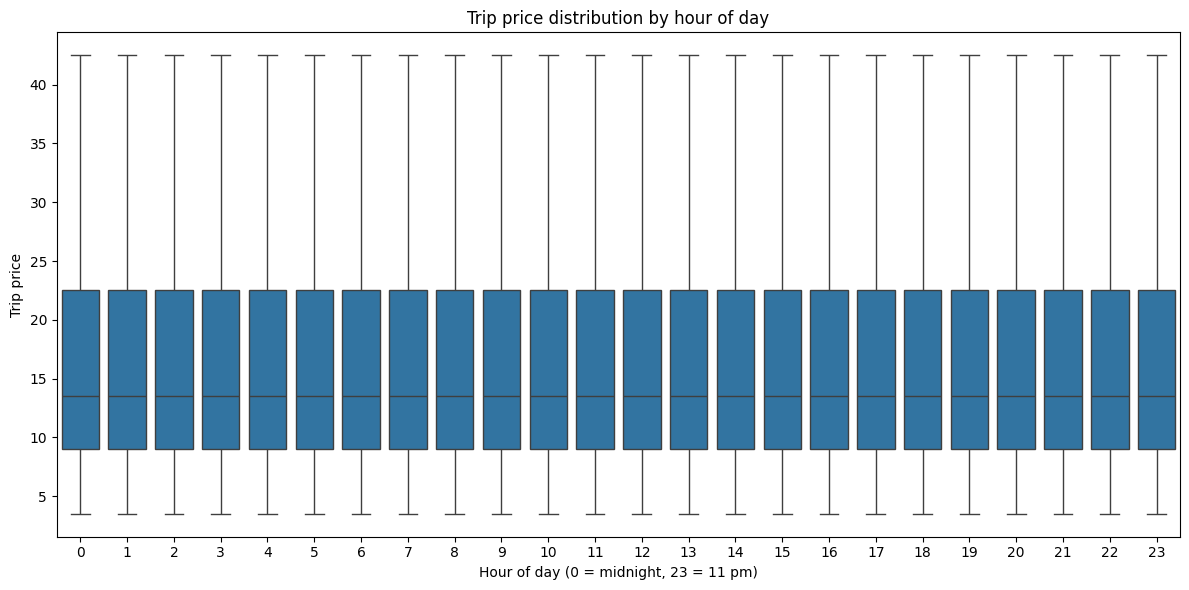

,hour,mean,median,count
0,0,16.382887,13.5,29305
1,1,16.363939,13.5,25823
2,2,16.360525,13.5,25830
3,3,16.377077,13.5,25101
4,4,16.419739,13.5,25660


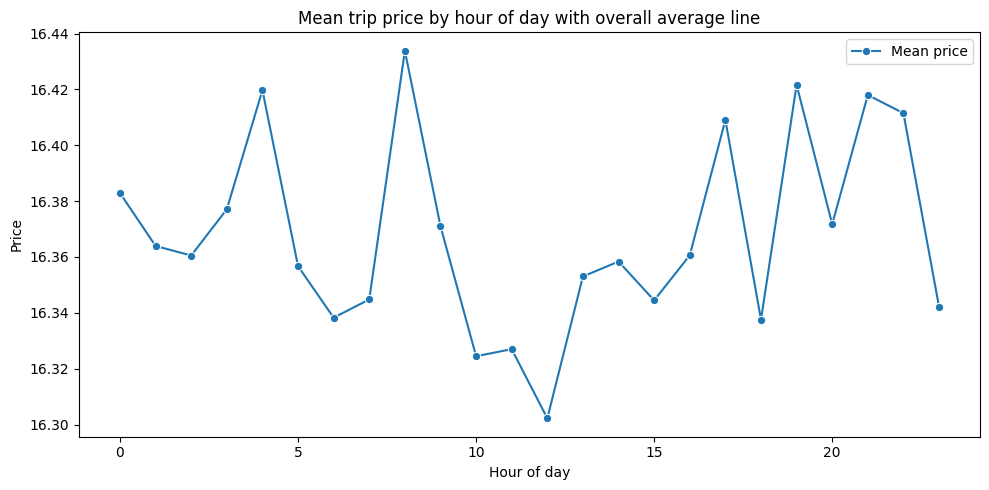

In [11]:
# ============================================================
# Price distribution by time of day
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

# Use only rows with a valid price
price_hour_df = df[['hour', 'price']].dropna()

# Optional: clip extreme outliers so the plot is readable
q_low, q_high = price_hour_df['price'].quantile([0.01, 0.99])
price_hour_df = price_hour_df[
    (price_hour_df['price'] >= q_low) & (price_hour_df['price'] <= q_high)
]

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=price_hour_df,
    x='hour',
    y='price',
    showfliers=False
)
plt.xlabel("Hour of day (0 = midnight, 23 = 11 pm)")
plt.ylabel("Trip price")
plt.title("Trip price distribution by hour of day")
plt.tight_layout()
plt.show()

# Mean and median price by hour of day
hour_stats = (
    price_hour_df
    .groupby('hour')['price']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)

display(hour_stats.head())

plt.figure(figsize=(10, 5))

# Main hourly mean price line
sns.lineplot(
    data=hour_stats,
    x='hour',
    y='mean',
    marker='o',
    label='Mean price'
)

plt.xlabel("Hour of day")
plt.ylabel("Price")
plt.title("Mean trip price by hour of day with overall average line")
plt.legend()
plt.tight_layout()
plt.show()

#### Removing Outliers

In [12]:
df_no_outliers = df_clean.copy()

def iqr_filter(df, col, k=1.5):
    """Apply IQR rule to a single column and return filtered df."""
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    before = df.shape[0]
    df_filtered = df[(df[col] >= lower) & (df[col] <= upper)].copy()
    after = df_filtered.shape[0]

    print(f"\n[{col}] IQR Filtering")
    print(f"Q1={Q1:.3f}, Q3={Q3:.3f}, IQR={IQR:.3f}")
    print(f"Lower Bound={lower:.3f}, Upper Bound={upper:.3f}")
    print(f"Rows removed: {before - after}")

    return df_filtered

# Remove outliers for PRICE and DISTANCE
df_no_outliers = iqr_filter(df_no_outliers, "price", k=1.5)
df_no_outliers = iqr_filter(df_no_outliers, "distance", k=1.5)

print("\nFinal shape after outlier removal:", df_no_outliers.shape)


[price] IQR Filtering
Q1=9.000, Q3=22.500, IQR=13.500
Lower Bound=-11.250, Upper Bound=42.750
Rows removed: 5589

[distance] IQR Filtering
Q1=1.270, Q3=2.900, IQR=1.630
Lower Bound=-1.175, Upper Bound=5.345
Rows removed: 7158

Final shape after outlier removal: (625229, 36)


#### Feature Engineering

In [13]:
# 1. Parse datetime
df_no_outliers["datetime"] = pd.to_datetime(df_no_outliers["datetime"])

# 2. Convert month number -> month name
df_no_outliers["month_name"] = df_no_outliers["datetime"].dt.month_name()

# 3. Add weekday names (Monday, Tuesday, ...)
df_no_outliers["day_name"] = df_no_outliers["datetime"].dt.day_name()

# 4. Weekend flag as categorical yes/no
df_no_outliers["is_weekend"] = np.where(
    df_no_outliers["day_name"].isin(["Saturday", "Sunday"]),
    "yes",
    "no",
)

# 5. Peak hour flag as categorical yes/no
# Morning peak: 7, 8, 9
# Evening peak: 16, 17, 18, 19, 20
peak_hours = [7, 8, 9, 16, 17, 18, 19, 20]
df_no_outliers["is_peak_hour"] = np.where(
    df_no_outliers["hour"].isin(peak_hours),
    "yes",
    "no",
)

# Preview
print(
    df_no_outliers[
        [
            "datetime",
            "hour",
            "month",
            "month_name",
            "day_name",
            "is_weekend",
            "is_peak_hour",
        ]
    ].head()
)

# 6. Drop raw datetime column
df_no_outliers = df_no_outliers.drop(columns=["datetime"])

# 7. Drop numeric day of month
df_no_outliers = df_no_outliers.drop(columns=["day"])

# 8. Drop numeric month column (we replaced it with month_name)
df_no_outliers = df_no_outliers.drop(columns=["month"])

df_no_outliers.head()

             datetime  hour  month month_name   day_name is_weekend  \
0 2018-12-16 09:30:07     9     12   December     Sunday        yes   
1 2018-11-27 02:00:23     2     11   November    Tuesday         no   
2 2018-11-28 01:00:22     1     11   November  Wednesday         no   
3 2018-11-30 04:53:02     4     11   November     Friday         no   
4 2018-11-29 03:49:20     3     11   November   Thursday         no   

  is_peak_hour  
0          yes  
1           no  
2           no  
3           no  
4           no  


,hour,source,destination,cab_type,name,price,distance,surge_multiplier,temperature,apparentTemperature,...,moonPhase,precipIntensityMax,temperatureMin,temperatureMax,apparentTemperatureMin,apparentTemperatureMax,month_name,day_name,is_weekend,is_peak_hour
0,9,Haymarket Square,North Station,Lyft,Shared,5.0,0.44,1.0,42.34,37.12,...,0.30,0.1276,39.89,43.68,33.73,38.07,December,Sunday,yes,yes
1,2,Haymarket Square,North Station,Lyft,Lux,11.0,0.44,1.0,43.58,37.35,...,0.64,0.1300,40.49,47.30,36.20,43.92,November,Tuesday,no,no
2,1,Haymarket Square,North Station,Lyft,Lyft,7.0,0.44,1.0,38.33,32.93,...,0.68,0.1064,35.36,47.55,31.04,44.12,November,Wednesday,no,no
3,4,Haymarket Square,North Station,Lyft,Lux Black XL,26.0,0.44,1.0,34.38,29.63,...,0.75,0.0000,34.67,45.03,30.30,38.53,November,Friday,no,no
4,3,Haymarket Square,North Station,Lyft,Lyft XL,9.0,0.44,1.0,37.44,30.88,...,0.72,0.0001,33.10,42.18,29.11,35.75,November,Thursday,no,no


#### VIF Analysis

In [14]:
df_vif = df_no_outliers.copy()  # start from your cleaned dataframe

# Select numeric columns and exclude target
numeric_cols = df_vif.select_dtypes(include=["float64", "int64"]).columns.tolist()
if "price" in numeric_cols:
    numeric_cols.remove("price")

print("Initial numeric columns for VIF:")
print(numeric_cols)

vif_threshold = 10.0
dropped_features = []

def compute_vif(df, features):
    """Compute VIF for a list of numeric features."""
    X = df[features].values
    vif_data = []
    for i, col in enumerate(features):
        vif_val = variance_inflation_factor(X, i)
        vif_data.append({"feature": col, "vif": vif_val})
    vif_df = (
        pd.DataFrame(vif_data)
        .sort_values("vif", ascending=False)
        .reset_index(drop=True)
    )
    return vif_df

iteration = 1

# ---- VIF LOOP ----
while True:
    print(f"\nIteration {iteration}")
    vif_df = compute_vif(df_vif, numeric_cols)
    display(vif_df)

    max_vif = vif_df["vif"].max()
    if max_vif < vif_threshold:
        print(f"All remaining features have VIF < {vif_threshold}. Stopping VIF elimination loop.")
        break

    # feature with highest VIF
    row_max = vif_df.loc[vif_df["vif"].idxmax()]
    feature_to_drop = row_max["feature"]
    feature_vif = row_max["vif"]

    print(f"Dropping feature: {feature_to_drop} with VIF = {feature_vif:.4f}")

    numeric_cols.remove(feature_to_drop)
    dropped_features.append((feature_to_drop, feature_vif))
    df_vif = df_vif.drop(columns=[feature_to_drop])

    iteration += 1

print("\nFinal numeric features after VIF filtering:")
print(numeric_cols)

# ---- FINAL VIF TABLE ----
print("\nRecomputing VIF with final numeric feature set:")
final_vif_df = compute_vif(df_vif, numeric_cols)
display(final_vif_df)

# ---- REPORT DROPPED FEATURES ----
print("\nDropped features due to high VIF:")
for feat, v in dropped_features:
    print(f"• {feat}: VIF = {v:.4f}")

Initial numeric columns for VIF:
['hour', 'distance', 'surge_multiplier', 'temperature', 'apparentTemperature', 'precipIntensity', 'precipProbability', 'humidity', 'windSpeed', 'windGust', 'visibility', 'temperatureHigh', 'temperatureLow', 'apparentTemperatureHigh', 'apparentTemperatureLow', 'dewPoint', 'pressure', 'windBearing', 'cloudCover', 'uvIndex', 'ozone', 'moonPhase', 'precipIntensityMax', 'temperatureMin', 'temperatureMax', 'apparentTemperatureMin', 'apparentTemperatureMax']

Iteration 1


,feature,vif
0,temperatureHigh,2.182291e+06
1,temperatureMax,2.176357e+06
2,apparentTemperatureHigh,6.376403e+05
3,apparentTemperatureMax,6.374346e+05
4,temperature,2.132695e+04
5,dewPoint,1.148509e+04
6,pressure,1.029487e+04
7,humidity,7.487001e+03
8,apparentTemperature,2.140717e+03
9,apparentTemperatureMin,1.721038e+03


Dropping feature: temperatureHigh with VIF = 2182290.7596

Iteration 2


,feature,vif
0,temperature,20975.174650
1,dewPoint,11216.888284
2,pressure,10177.037610
3,humidity,7352.777144
4,apparentTemperatureMax,4896.980390
5,temperatureMax,4204.177314
6,apparentTemperatureHigh,2739.014901
7,apparentTemperature,2137.966512
8,apparentTemperatureMin,1682.168107
9,temperatureMin,1343.468772


Dropping feature: temperature with VIF = 20975.1747

Iteration 3


,feature,vif
0,apparentTemperatureMax,4880.556031
1,temperatureMax,3999.512149
2,apparentTemperatureHigh,2715.222378
3,pressure,2092.436801
4,dewPoint,1741.937664
5,apparentTemperatureMin,1682.051979
6,apparentTemperature,1459.242126
7,temperatureMin,1341.514920
8,humidity,1214.944385
9,temperatureLow,819.598984


Dropping feature: apparentTemperatureMax with VIF = 4880.5560

Iteration 4


,feature,vif
0,pressure,2091.355310
1,dewPoint,1733.311922
2,temperatureMax,1636.642343
3,apparentTemperature,1449.202394
4,humidity,1199.240077
5,temperatureMin,1117.680526
6,apparentTemperatureMin,928.936181
7,apparentTemperatureHigh,843.966891
8,temperatureLow,768.889933
9,ozone,436.160802


Dropping feature: pressure with VIF = 2091.3553

Iteration 5


,feature,vif
0,temperatureMax,1512.029187
1,temperatureMin,1115.401194
2,apparentTemperatureMin,928.862866
3,apparentTemperatureHigh,808.564698
4,dewPoint,770.143010
5,temperatureLow,722.716174
6,apparentTemperature,688.195065
7,humidity,430.661234
8,ozone,358.839056
9,apparentTemperatureLow,337.309140


Dropping feature: temperatureMax with VIF = 1512.0292

Iteration 6


,feature,vif
0,temperatureMin,957.617514
1,apparentTemperatureMin,850.873423
2,dewPoint,754.604991
3,temperatureLow,705.678784
4,apparentTemperature,650.705230
5,humidity,416.349807
6,ozone,357.933327
7,apparentTemperatureLow,337.001147
8,apparentTemperatureHigh,237.907501
9,surge_multiplier,138.938519


Dropping feature: temperatureMin with VIF = 957.6175

Iteration 7


,feature,vif
0,dewPoint,754.413965
1,temperatureLow,703.933558
2,apparentTemperature,650.703627
3,humidity,413.504937
4,apparentTemperatureLow,329.870519
5,ozone,318.386895
6,apparentTemperatureHigh,235.404913
7,apparentTemperatureMin,214.357537
8,surge_multiplier,138.854786
9,windSpeed,76.429316


Dropping feature: dewPoint with VIF = 754.4140

Iteration 8


,feature,vif
0,temperatureLow,702.691861
1,apparentTemperatureLow,329.039961
2,ozone,195.305731
3,apparentTemperatureHigh,194.939633
4,apparentTemperatureMin,174.352985
5,surge_multiplier,128.969055
6,apparentTemperature,117.732582
7,humidity,103.606310
8,windSpeed,64.432816
9,windGust,38.168122


Dropping feature: temperatureLow with VIF = 702.6919

Iteration 9


,feature,vif
0,apparentTemperatureHigh,178.138665
1,ozone,160.765334
2,surge_multiplier,128.655090
3,apparentTemperature,117.495409
4,apparentTemperatureMin,110.717127
5,humidity,98.651866
6,windSpeed,63.771231
7,windGust,37.144352
8,visibility,36.973925
9,apparentTemperatureLow,31.895688


Dropping feature: apparentTemperatureHigh with VIF = 178.1387

Iteration 10


,feature,vif
0,ozone,159.081180
1,surge_multiplier,124.562946
2,apparentTemperatureMin,94.225035
3,humidity,91.377452
4,apparentTemperature,89.264881
5,windSpeed,62.716353
6,windGust,36.872664
7,visibility,36.837324
8,apparentTemperatureLow,29.707110
9,windBearing,14.581396


Dropping feature: ozone with VIF = 159.0812

Iteration 11


,feature,vif
0,surge_multiplier,93.938186
1,apparentTemperatureMin,93.121425
2,apparentTemperature,88.176130
3,humidity,80.724651
4,windSpeed,61.315052
5,windGust,36.351956
6,visibility,32.397227
7,apparentTemperatureLow,29.615161
8,windBearing,14.272255
9,moonPhase,12.325161


Dropping feature: surge_multiplier with VIF = 93.9382

Iteration 12


,feature,vif
0,apparentTemperatureMin,88.623841
1,apparentTemperature,81.237096
2,windSpeed,61.103241
3,humidity,55.889782
4,windGust,36.133755
5,apparentTemperatureLow,29.416178
6,visibility,25.283488
7,windBearing,14.193565
8,moonPhase,12.308033
9,cloudCover,7.973321


Dropping feature: apparentTemperatureMin with VIF = 88.6238

Iteration 13


,feature,vif
0,windSpeed,56.029801
1,humidity,50.201288
2,apparentTemperature,37.641976
3,windGust,35.142533
4,apparentTemperatureLow,29.271807
5,visibility,25.039974
6,windBearing,13.892350
7,moonPhase,11.123861
8,cloudCover,7.391167
9,precipProbability,6.899487


Dropping feature: windSpeed with VIF = 56.0298

Iteration 14


,feature,vif
0,humidity,50.165797
1,apparentTemperature,37.587715
2,apparentTemperatureLow,27.583635
3,visibility,22.760269
4,windBearing,13.753851
5,moonPhase,10.952450
6,cloudCover,7.375011
7,precipProbability,6.615614
8,windGust,5.691051
9,hour,5.417582


Dropping feature: humidity with VIF = 50.1658

Iteration 15


,feature,vif
0,apparentTemperature,30.264667
1,apparentTemperatureLow,25.349193
2,visibility,21.378724
3,windBearing,11.498100
4,moonPhase,10.759196
5,cloudCover,6.549479
6,precipProbability,5.783461
7,windGust,5.542331
8,hour,5.029220
9,distance,5.013119


Dropping feature: apparentTemperature with VIF = 30.2647

Iteration 16


,feature,vif
0,visibility,20.237585
1,apparentTemperatureLow,19.979776
2,windBearing,11.477466
3,moonPhase,10.060139
4,precipProbability,5.747013
5,cloudCover,5.657475
6,windGust,5.501512
7,distance,4.954562
8,hour,4.839185
9,precipIntensity,4.337228


Dropping feature: visibility with VIF = 20.2376

Iteration 17


,feature,vif
0,apparentTemperatureLow,11.924594
1,windBearing,9.814652
2,moonPhase,9.431452
3,cloudCover,5.617902
4,precipProbability,4.882746
5,distance,4.753133
6,windGust,4.606727
7,hour,4.589875
8,precipIntensity,4.324394
9,precipIntensityMax,2.915383


Dropping feature: apparentTemperatureLow with VIF = 11.9246

Iteration 18


,feature,vif
0,windBearing,9.511397
1,moonPhase,7.572177
2,cloudCover,5.321990
3,precipProbability,4.854915
4,windGust,4.327368
5,distance,4.237078
6,hour,4.235530
7,precipIntensity,4.214755
8,precipIntensityMax,2.800447
9,uvIndex,1.458000


All remaining features have VIF < 10.0. Stopping VIF elimination loop.

Final numeric features after VIF filtering:
['hour', 'distance', 'precipIntensity', 'precipProbability', 'windGust', 'windBearing', 'cloudCover', 'uvIndex', 'moonPhase', 'precipIntensityMax']

Recomputing VIF with final numeric feature set:


,feature,vif
0,windBearing,9.511397
1,moonPhase,7.572177
2,cloudCover,5.321990
3,precipProbability,4.854915
4,windGust,4.327368
5,distance,4.237078
6,hour,4.235530
7,precipIntensity,4.214755
8,precipIntensityMax,2.800447
9,uvIndex,1.458000



Dropped features due to high VIF:
• temperatureHigh: VIF = 2182290.7596
• temperature: VIF = 20975.1747
• apparentTemperatureMax: VIF = 4880.5560
• pressure: VIF = 2091.3553
• temperatureMax: VIF = 1512.0292
• temperatureMin: VIF = 957.6175
• dewPoint: VIF = 754.4140
• temperatureLow: VIF = 702.6919
• apparentTemperatureHigh: VIF = 178.1387
• ozone: VIF = 159.0812
• surge_multiplier: VIF = 93.9382
• apparentTemperatureMin: VIF = 88.6238
• windSpeed: VIF = 56.0298
• humidity: VIF = 50.1658
• apparentTemperature: VIF = 30.2647
• visibility: VIF = 20.2376
• apparentTemperatureLow: VIF = 11.9246


#### PCA Analysis


--------------------------------------------------
VARIABLES SELECTED FOR PCA (Numeric Predictors):
--------------------------------------------------
• hour
• distance
• precipIntensity
• precipProbability
• windGust
• windBearing
• cloudCover
• uvIndex
• moonPhase
• precipIntensityMax

Total numeric variables used in PCA: 10


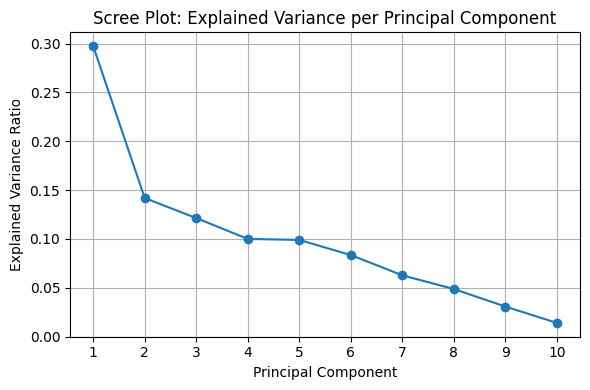

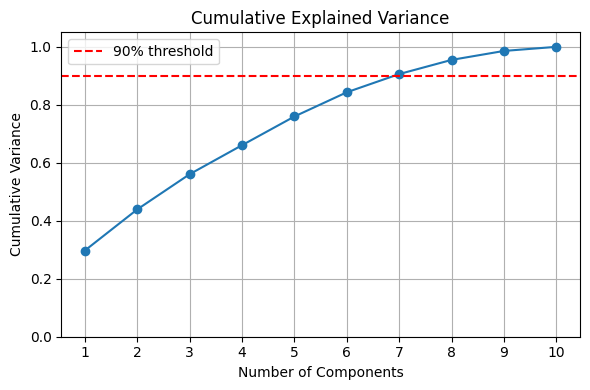


Explained variance and cumulative variance per component:
PC1: variance = 0.2973, cumulative = 0.2973
PC2: variance = 0.1419, cumulative = 0.4392
PC3: variance = 0.1214, cumulative = 0.5606
PC4: variance = 0.1001, cumulative = 0.6607
PC5: variance = 0.0990, cumulative = 0.7597
PC6: variance = 0.0836, cumulative = 0.8433
PC7: variance = 0.0628, cumulative = 0.9061
PC8: variance = 0.0488, cumulative = 0.9550
PC9: variance = 0.0309, cumulative = 0.9859
PC10: variance = 0.0141, cumulative = 1.0000

Number of PCs required to reach 90 percent variance: 7

Shape of PCA transformed data: (625229, 7)

Feature importance based on average absolute PCA loadings:


cloudCover            0.293719
windGust              0.293549
uvIndex               0.289383
moonPhase             0.288011
hour                  0.282665
windBearing           0.196168
distance              0.180906
precipIntensity       0.171746
precipIntensityMax    0.168620
precipProbability     0.131155
dtype: float64

In [15]:
print("\n--------------------------------------------------")
print("VARIABLES SELECTED FOR PCA (Numeric Predictors):")
print("--------------------------------------------------")

# Use the final numeric features from the VIF step
numeric_cols_final = [
    "hour",
    "distance",
    "precipIntensity",
    "precipProbability",
    "windGust",
    "windBearing",
    "cloudCover",
    "uvIndex",
    "moonPhase",
    "precipIntensityMax",
]

for col in numeric_cols_final:
    print(f"• {col}")

print("\nTotal numeric variables used in PCA:", len(numeric_cols_final))

# -----------------------------------------------------------
# 1. STANDARDIZE NUMERIC DATA
# -----------------------------------------------------------

X_num = df_vif[numeric_cols_final]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# -----------------------------------------------------------
# 2. PCA WITH ALL COMPONENTS — FOR PLOTTING FIRST
# -----------------------------------------------------------

pca_full = PCA(n_components=None)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

# -----------------------------------------------------------
# 3. SCREE PLOT
# -----------------------------------------------------------

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(explained_var) + 1), explained_var, marker="o")
plt.title("Scree Plot: Explained Variance per Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(range(1, len(explained_var) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# 4. CUMULATIVE VARIANCE PLOT
# -----------------------------------------------------------

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.90, linestyle="--", color="red", label="90% threshold")
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.ylim(0, 1.05)
plt.xticks(range(1, len(cum_var) + 1))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Show variance numbers
print("\nExplained variance and cumulative variance per component:")
for i, (v, cv) in enumerate(zip(explained_var, cum_var), start=1):
    print(f"PC{i}: variance = {v:.4f}, cumulative = {cv:.4f}")

# -----------------------------------------------------------
# 5. DETERMINE NUMBER OF COMPONENTS FOR 90 PERCENT VARIANCE
# -----------------------------------------------------------

threshold = 0.90
n_components_90 = np.searchsorted(cum_var, threshold) + 1
print(f"\nNumber of PCs required to reach 90 percent variance: {n_components_90}")

# -----------------------------------------------------------
# 6. REFIT PCA WITH THE SELECTED NUMBER OF COMPONENTS
# -----------------------------------------------------------

pca_final = PCA(n_components=n_components_90)
X_pca_final = pca_final.fit_transform(X_scaled)

print("\nShape of PCA transformed data:", X_pca_final.shape)

# -----------------------------------------------------------
# 7. FEATURE IMPORTANCE VIA PCA LOADINGS
# -----------------------------------------------------------

loadings = pd.DataFrame(
    pca_final.components_.T,
    index=numeric_cols_final,
    columns=[f"PC{i}" for i in range(1, n_components_90 + 1)],
)

importance = loadings.abs().mean(axis=1).sort_values(ascending=False)

print("\nFeature importance based on average absolute PCA loadings:")
display(importance)

#### Defining Feature List

In [16]:
TARGET_COLUMN = "price"

# ----------------------------------------------------
# NUMERIC FEATURES (VIF-approved only)
# ----------------------------------------------------
NUMERIC_FEATURES = [
    "hour",
    "distance",
    "precipIntensity",
    "precipProbability",
    "windGust",
    "windBearing",
    "cloudCover",
    "uvIndex",
    "moonPhase",
    "precipIntensityMax",
]

# ----------------------------------------------------
# CATEGORICAL FEATURES
# ----------------------------------------------------
CATEGORICAL_FEATURES = [
    "cab_type",
    "name",
    "source",
    "destination",
    "short_summary",
    "day_name",
    "month_name",
    "is_weekend",
    "is_peak_hour",
]

print("Numeric features:", NUMERIC_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)

Numeric features: ['hour', 'distance', 'precipIntensity', 'precipProbability', 'windGust', 'windBearing', 'cloudCover', 'uvIndex', 'moonPhase', 'precipIntensityMax']
Categorical features: ['cab_type', 'name', 'source', 'destination', 'short_summary', 'day_name', 'month_name', 'is_weekend', 'is_peak_hour']


#### Train-Test Split

In [17]:
all_features = NUMERIC_FEATURES + CATEGORICAL_FEATURES

df_model = df_vif[all_features + [TARGET_COLUMN]].copy()

X = df_model[all_features]
y = df_model[TARGET_COLUMN]

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=508,
    shuffle=True,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

X shape: (625229, 19)
y shape: (625229,)
Train shape: (500183, 19)
Test shape: (125046, 19)


#### Transforming Variables

In [18]:
# numeric: just scale, since we dropped all nulls
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# categorical: one hot with drop first like you prefer
categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUMERIC_FEATURES),
        ("cat", categorical_transformer, CATEGORICAL_FEATURES),
    ]
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


### Models

In [19]:
model_results = []  # we will append a dict for each model

#### Linear Regression

##### Grid Search

In [20]:
# Linear Regression pipeline
linreg_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LinearRegression())
    ]
)

# Hyperparameter grid
linreg_param_grid = {
    "model__fit_intercept": [True, False],
    "model__positive": [False, True],
}

linreg_grid = GridSearchCV(
    estimator=linreg_pipeline,
    param_grid=linreg_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

linreg_grid.fit(X_train, y_train)

print("Best Linear Regression params:", linreg_grid.best_params_)
print("Best CV RMSE:", -linreg_grid.best_score_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Linear Regression params: {'model__fit_intercept': True, 'model__positive': False}
Best CV RMSE: 2.452453872823892


##### Evaluation

In [21]:
# Use the best found Linear Regression model
best_linreg = linreg_grid.best_estimator_

# Predictions on test data
y_pred_linreg = best_linreg.predict(X_test)

# Evaluation metrics
mse_linreg = mean_squared_error(y_test, y_pred_linreg)
rmse_linreg = np.sqrt(mse_linreg)
mae_linreg = mean_absolute_error(y_test, y_pred_linreg)
r2_linreg = r2_score(y_test, y_pred_linreg)

print("\nLinear Regression performance on test set:")
print(f"RMSE: {rmse_linreg:.4f}")
print(f"MAE:  {mae_linreg:.4f}")
print(f"R^2:  {r2_linreg:.4f}")

# Store results for later comparison
model_results.append({
    "model": "LinearRegression",
    "best_params": linreg_grid.best_params_,
    "rmse": rmse_linreg,
    "mae": mae_linreg,
    "r2": r2_linreg,
})


Linear Regression performance on test set:
RMSE: 2.4547
MAE:  1.7336
R^2:  0.9207


##### Most Important Features

In [22]:
def show_linear_model_importance(trained_pipeline, top_n=20, title=""):
    """
    trained_pipeline: fitted Pipeline with steps ["preprocess", "model"]
    model must have a .coef_ attribute
    """
    pre = trained_pipeline.named_steps["preprocess"]
    model = trained_pipeline.named_steps["model"]
    
    feature_names = pre.get_feature_names_out()
    coefs = model.coef_.ravel()  # flatten just in case

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "coef": coefs,
        "abs_coef": np.abs(coefs)
    }).sort_values("abs_coef", ascending=False)

    print(f"\nTop {top_n} features for {title}:")
    display(importance_df.head(top_n))

show_linear_model_importance(best_linreg, top_n=20, title="Linear Regression")


Top 20 features for Linear Regression:


,feature,coef,abs_coef
14,cat__name_Lux Black XL,13.657087,13.657087
18,cat__name_UberPool,-11.550071,11.550071
17,cat__name_Shared,-11.517745,11.517745
19,cat__name_UberX,-10.572410,10.572410
21,cat__name_WAV,-10.559823,10.559823
11,cat__name_Black SUV,9.659856,9.659856
15,cat__name_Lyft,-7.943195,7.943195
13,cat__name_Lux Black,5.148701,5.148701
20,cat__name_UberXL,-4.754053,4.754053
1,num__distance,3.025895,3.025895


#### Decision Tree Regressor

##### Grid Search

In [23]:
# Decision Tree pipeline
dt_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", DecisionTreeRegressor(random_state=508))
    ]
)

# Hyperparameter grid for Decision Tree
dt_param_grid = {
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 20],
    "model__min_samples_leaf": [1, 10],
}

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    scoring="neg_root_mean_squared_error",  # RMSE
    cv=3,
    n_jobs=-1,
    verbose=1,
)

dt_grid.fit(X_train, y_train)

print("Best Decision Tree params:", dt_grid.best_params_)
print("Best CV RMSE:", -dt_grid.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Decision Tree params: {'model__max_depth': 20, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}
Best CV RMSE: 2.090779994143074


##### Evaluation

In [24]:
# Best Decision Tree model
best_dt = dt_grid.best_estimator_

# Predictions
y_pred_dt = best_dt.predict(X_test)

# Metrics
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("\nDecision Tree performance on test set:")
print(f"RMSE: {rmse_dt:.4f}")
print(f"MAE:  {mae_dt:.4f}")
print(f"R^2:  {r2_dt:.4f}")

# Save for comparison
model_results.append({
    "model": "DecisionTreeRegressor",
    "best_params": dt_grid.best_params_,
    "rmse": rmse_dt,
    "mae": mae_dt,
    "r2": r2_dt,
})


Decision Tree performance on test set:
RMSE: 2.0652
MAE:  1.2724
R^2:  0.9438


##### Most Important Features

In [25]:
def show_tree_model_importance(trained_pipeline, top_n=20, title=""):
    """
    trained_pipeline: fitted Pipeline with steps ["preprocess", "model"]
    model must have .feature_importances_
    """
    pre = trained_pipeline.named_steps["preprocess"]
    model = trained_pipeline.named_steps["model"]
    
    feature_names = pre.get_feature_names_out()
    importances = model.feature_importances_

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    print(f"\nTop {top_n} features for {title}:")
    display(importance_df.head(top_n))

show_tree_model_importance(best_dt, top_n=20, title="Decision Tree Regressor")


Top 20 features for Decision Tree Regressor:


,feature,importance
11,cat__name_Black SUV,0.285631
14,cat__name_Lux Black XL,0.248429
1,num__distance,0.131488
13,cat__name_Lux Black,0.103550
17,cat__name_Shared,0.052247
15,cat__name_Lyft,0.044788
19,cat__name_UberX,0.037859
21,cat__name_WAV,0.035434
18,cat__name_UberPool,0.030487
20,cat__name_UberXL,0.009399


#### Linear SVR

##### Grid Search

In [26]:
svr_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LinearSVR(random_state=508, max_iter=5000))
    ]
)

svr_param_grid = {
    "model__C": [0.1, 1.0, 10.0],
    "model__epsilon": [0.0, 0.1],
}

svr_grid = GridSearchCV(
    estimator=svr_pipeline,
    param_grid=svr_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

svr_grid.fit(X_train, y_train)

print("Best Linear SVR params:", svr_grid.best_params_)
print("Best CV RMSE:", -svr_grid.best_score_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Linear SVR params: {'model__C': 10.0, 'model__epsilon': 0.1}
Best CV RMSE: 2.5021635681682977


##### Evaluation

In [27]:
best_svr = svr_grid.best_estimator_

y_pred_svr = best_svr.predict(X_test)

mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("\nLinear SVR performance on test set:")
print(f"RMSE: {rmse_svr:.4f}")
print(f"MAE:  {mae_svr:.4f}")
print(f"R^2:  {r2_svr:.4f}")

model_results.append({
    "model": "LinearSVR",
    "best_params": svr_grid.best_params_,
    "rmse": rmse_svr,
    "mae": mae_svr,
    "r2": r2_svr,
})


Linear SVR performance on test set:
RMSE: 2.5042
MAE:  1.6889
R^2:  0.9174


##### Most Important Features

In [28]:
show_linear_model_importance(best_svr, top_n=20, title="Linear SVR")


Top 20 features for Linear SVR:


,feature,coef,abs_coef
14,cat__name_Lux Black XL,15.391455,15.391455
18,cat__name_UberPool,-11.055615,11.055615
19,cat__name_UberX,-10.234217,10.234217
21,cat__name_WAV,-10.215345,10.215345
11,cat__name_Black SUV,9.879366,9.879366
17,cat__name_Shared,-8.852292,8.852292
13,cat__name_Lux Black,6.851941,6.851941
15,cat__name_Lyft,-5.697634,5.697634
20,cat__name_UberXL,-4.949316,4.949316
10,cat__cab_type_Uber,4.827887,4.827887


#### Neural Network Regressor

##### Grid Search

In [29]:
# MLPRegressor pipeline
mlp_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", MLPRegressor(
            random_state=508,
            max_iter=300
        ))
    ]
)

# Hyperparameter grid for MLP
mlp_param_grid = {
    "model__hidden_layer_sizes": [(50,), (100,), (50, 50)],
    "model__alpha": [0.0001, 0.001],
    "model__learning_rate_init": [0.001, 0.01],
}

mlp_grid = GridSearchCV(
    estimator=mlp_pipeline,
    param_grid=mlp_param_grid,
    scoring="neg_root_mean_squared_error",  # RMSE
    cv=3,
    n_jobs=-1,
    verbose=1
)

mlp_grid.fit(X_train, y_train)

print("Best MLP params:", mlp_grid.best_params_)
print("Best CV RMSE:", -mlp_grid.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best MLP params: {'model__alpha': 0.001, 'model__hidden_layer_sizes': (50,), 'model__learning_rate_init': 0.001}
Best CV RMSE: 2.0107663625857075


##### Evaluation

In [30]:
best_mlp = mlp_grid.best_estimator_

# Predictions
y_pred_mlp = best_mlp.predict(X_test)

# Metrics
mse_mlp = mean_squared_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mse_mlp)
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

print("\nMLPRegressor performance on test set:")
print(f"RMSE: {rmse_mlp:.4f}")
print(f"MAE:  {mae_mlp:.4f}")
print(f"R^2:  {r2_mlp:.4f}")

# Store for comparison
model_results.append({
    "model": "MLPRegressor",
    "best_params": mlp_grid.best_params_,
    "rmse": rmse_mlp,
    "mae": mae_mlp,
    "r2": r2_mlp,
})


MLPRegressor performance on test set:
RMSE: 2.0029
MAE:  1.2441
R^2:  0.9472


#### Random Forest Regressor

##### Grid Search

In [31]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(
            random_state=508,
            n_jobs=-1
        ))
    ]
)

rf_param_grid = {
    "model__n_estimators": [40],
    "model__max_depth": [None, 15],
    "model__min_samples_leaf": [1, 5]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest params:", rf_grid.best_params_)
print("Best CV RMSE:", -rf_grid.best_score_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Random Forest params: {'model__max_depth': 15, 'model__min_samples_leaf': 5, 'model__n_estimators': 40}
Best CV RMSE: 2.02124173097992


##### Evaluation

In [32]:
best_rf = rf_grid.best_estimator_

y_pred_rf = best_rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest performance on test set:")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE:  {mae_rf:.4f}")
print(f"R^2:  {r2_rf:.4f}")

model_results.append({
    "model": "RandomForestRegressor",
    "best_params": rf_grid.best_params_,
    "rmse": rmse_rf,
    "mae": mae_rf,
    "r2": r2_rf,
})


Random Forest performance on test set:
RMSE: 2.0128
MAE:  1.2455
R^2:  0.9467


##### Most Important Features

In [33]:
show_tree_model_importance(best_rf, top_n=20, title="Random Forest Regressor")


Top 20 features for Random Forest Regressor:


,feature,importance
11,cat__name_Black SUV,0.286698
14,cat__name_Lux Black XL,0.249329
1,num__distance,0.130956
13,cat__name_Lux Black,0.103867
17,cat__name_Shared,0.052385
15,cat__name_Lyft,0.044969
19,cat__name_UberX,0.037338
21,cat__name_WAV,0.036282
18,cat__name_UberPool,0.030576
20,cat__name_UberXL,0.009261


#### XGBoost Regressor

##### Grid Search

In [34]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", XGBRegressor(
            random_state=508,
            n_jobs=-1,
            tree_method="hist",
            objective="reg:squarederror",
        ))
    ]
)

xgb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 6],
    "model__learning_rate": [0.05, 0.1],
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

xgb_grid.fit(X_train, y_train)

print("Best XGBoost params:", xgb_grid.best_params_)
print("Best CV RMSE:", -xgb_grid.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


Best XGBoost params: {'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 200}
Best CV RMSE: 1.989045377480848


##### Evaluation

In [35]:
best_xgb = xgb_grid.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)

mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\nXGBoost Regressor performance on test set:")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"MAE:  {mae_xgb:.4f}")
print(f"R^2:  {r2_xgb:.4f}")

model_results.append({
    "model": "XGBRegressor",
    "best_params": xgb_grid.best_params_,
    "rmse": rmse_xgb,
    "mae": mae_xgb,
    "r2": r2_xgb,
})


XGBoost Regressor performance on test set:
RMSE: 1.9870
MAE:  1.2316
R^2:  0.9480


##### Most Important Features

In [36]:
show_tree_model_importance(best_xgb, top_n=20, title="XGBoost Regressor")


Top 20 features for XGBoost Regressor:


,feature,importance
14,cat__name_Lux Black XL,0.344600
11,cat__name_Black SUV,0.258919
13,cat__name_Lux Black,0.101784
17,cat__name_Shared,0.094867
15,cat__name_Lyft,0.046783
18,cat__name_UberPool,0.040938
21,cat__name_WAV,0.036719
19,cat__name_UberX,0.036680
12,cat__name_Lux,0.017976
20,cat__name_UberXL,0.007751


#### KNN Regressor

##### Setting New Data Size

In [37]:
from sklearn.model_selection import train_test_split

# Subsample training data for KNN tuning
X_knn_sub, X_knn_val, y_knn_sub, y_knn_val = train_test_split(
    X_train,
    y_train,
    train_size=50000,   # reduce if needed
    random_state=508,
    shuffle=True,
)

print("KNN tuning subset shapes:")
print("X_knn_sub:", X_knn_sub.shape, "y_knn_sub:", y_knn_sub.shape)
print("X_knn_val:", X_knn_val.shape, "y_knn_val:", y_knn_val.shape)

KNN tuning subset shapes:
X_knn_sub: (50000, 19) y_knn_sub: (50000,)
X_knn_val: (450183, 19) y_knn_val: (450183,)


In [38]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import itertools

# Define hyperparameter grid
k_values = [5, 10]
weight_values = ["uniform", "distance"]
p_values = [1, 2]  # Manhattan vs Euclidean

param_combos = list(itertools.product(k_values, weight_values, p_values))
print("Total KNN combos:", len(param_combos))

best_rmse = np.inf
best_params = None

for n_neighbors, weights, p in param_combos:
    print(f"\nTesting KNN with n_neighbors={n_neighbors}, weights={weights}, p={p}")
    
    knn_pipeline = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", KNeighborsRegressor(
                n_neighbors=n_neighbors,
                weights=weights,
                p=p
            ))
        ]
    )
    
    # Fit on subset
    knn_pipeline.fit(X_knn_sub, y_knn_sub)
    
    # Validate on held-out subset
    y_val_pred = knn_pipeline.predict(X_knn_val)
    rmse_val = np.sqrt(mean_squared_error(y_knn_val, y_val_pred))
    
    print(f"Validation RMSE: {rmse_val:.4f}")
    
    if rmse_val < best_rmse:
        best_rmse = rmse_val
        best_params = {
            "n_neighbors": n_neighbors,
            "weights": weights,
            "p": p,
        }

print("\nBest KNN params from manual search:")
print(best_params)
print(f"Best validation RMSE: {best_rmse:.4f}")

Total KNN combos: 8

Testing KNN with n_neighbors=5, weights=uniform, p=1
Validation RMSE: 5.9622

Testing KNN with n_neighbors=5, weights=uniform, p=2
Validation RMSE: 6.1006

Testing KNN with n_neighbors=5, weights=distance, p=1
Validation RMSE: 5.6018

Testing KNN with n_neighbors=5, weights=distance, p=2
Validation RMSE: 5.6211

Testing KNN with n_neighbors=10, weights=uniform, p=1
Validation RMSE: 5.5282

Testing KNN with n_neighbors=10, weights=uniform, p=2
Validation RMSE: 5.6751

Testing KNN with n_neighbors=10, weights=distance, p=1
Validation RMSE: 5.1812

Testing KNN with n_neighbors=10, weights=distance, p=2
Validation RMSE: 5.2355

Best KNN params from manual search:
{'n_neighbors': 10, 'weights': 'distance', 'p': 1}
Best validation RMSE: 5.1812


In [39]:
# Final KNN trained on full training data
best_knn_full = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", KNeighborsRegressor(
            n_neighbors=best_params["n_neighbors"],
            weights=best_params["weights"],
            p=best_params["p"],
        ))
    ]
)

best_knn_full.fit(X_train, y_train)

# Evaluate on test set
y_pred_knn = best_knn_full.predict(X_test)

mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("\nKNN Regressor performance on test set (full train, tuned on subset):")
print(f"RMSE: {rmse_knn:.4f}")
print(f"MAE:  {mae_knn:.4f}")
print(f"R^2:  {r2_knn:.4f}")

model_results.append({
    "model": "KNeighborsRegressor",
    "best_params": best_params,
    "rmse": rmse_knn,
    "mae": mae_knn,
    "r2": r2_knn,
})


KNN Regressor performance on test set (full train, tuned on subset):
RMSE: 3.3635
MAE:  2.1269
R^2:  0.8510


#### Ensemble Method

##### GridSearch

In [40]:
gbr_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", GradientBoostingRegressor(
            random_state=508
        ))
    ]
)

gbr_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
}

gbr_grid = GridSearchCV(
    estimator=gbr_pipeline,
    param_grid=gbr_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

gbr_grid.fit(X_train, y_train)

print("Best Gradient Boosting params:", gbr_grid.best_params_)
print("Best CV RMSE:", -gbr_grid.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Gradient Boosting params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}
Best CV RMSE: 2.1214431994035867


##### Evaluation

In [41]:
best_gbr = gbr_grid.best_estimator_

y_pred_gbr = best_gbr.predict(X_test)

mse_gbr = mean_squared_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print("\nGradient Boosting Regressor performance on test set:")
print(f"RMSE: {rmse_gbr:.4f}")
print(f"MAE:  {mae_gbr:.4f}")
print(f"R^2:  {r2_gbr:.4f}")

model_results.append({
    "model": "GradientBoostingRegressor",
    "best_params": gbr_grid.best_params_,
    "rmse": rmse_gbr,
    "mae": mae_gbr,
    "r2": r2_gbr,
})


Gradient Boosting Regressor performance on test set:
RMSE: 2.1237
MAE:  1.3697
R^2:  0.9406


##### Feature Importance

In [42]:
show_tree_model_importance(best_gbr, top_n=20, title="Gradient Boosting Regressor")


Top 20 features for Gradient Boosting Regressor:


,feature,importance
11,cat__name_Black SUV,0.256549
14,cat__name_Lux Black XL,0.236204
1,num__distance,0.122300
17,cat__name_Shared,0.096459
13,cat__name_Lux Black,0.073617
18,cat__name_UberPool,0.062645
21,cat__name_WAV,0.049068
19,cat__name_UberX,0.045072
15,cat__name_Lyft,0.043942
10,cat__cab_type_Uber,0.004067


### Model Comparison

In [43]:
import pandas as pd

results_df = pd.DataFrame(model_results)

# Sort by RMSE ascending (lower is better)
results_df_sorted = results_df.sort_values("rmse", ascending=True).reset_index(drop=True)

print("Model comparison (sorted by RMSE):")
display(results_df_sorted)

# Identify best model by RMSE
best_idx = results_df_sorted["rmse"].idxmin()
best_model_name = results_df_sorted.loc[best_idx, "model"]

print(f"\nBest model based on RMSE: {best_model_name}")

Model comparison (sorted by RMSE):


,model,best_params,rmse,mae,r2
0,XGBRegressor,"{'model__learning_rate': 0.1, 'model__max_dept...",1.986972,1.231616,0.948013
1,MLPRegressor,"{'model__alpha': 0.001, 'model__hidden_layer_s...",2.002940,1.244119,0.947174
2,RandomForestRegressor,"{'model__max_depth': 15, 'model__min_samples_l...",2.012811,1.245504,0.946652
3,DecisionTreeRegressor,"{'model__max_depth': 20, 'model__min_samples_l...",2.065186,1.272362,0.943840
4,GradientBoostingRegressor,"{'model__learning_rate': 0.1, 'model__max_dept...",2.123673,1.369702,0.940614
5,LinearRegression,"{'model__fit_intercept': True, 'model__positiv...",2.454664,1.733595,0.920660
6,LinearSVR,"{'model__C': 10.0, 'model__epsilon': 0.1}",2.504229,1.688940,0.917423
7,KNeighborsRegressor,"{'n_neighbors': 10, 'weights': 'distance', 'p'...",3.363476,2.126862,0.851035



Best model based on RMSE: XGBRegressor


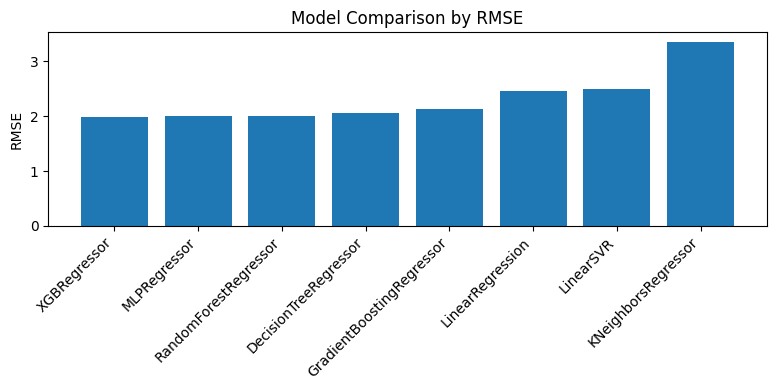

In [44]:
plt.figure(figsize=(8, 4))

models = results_df_sorted["model"]
rmses = results_df_sorted["rmse"]

bars = plt.bar(models, rmses)
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("Model Comparison by RMSE")
plt.tight_layout()
plt.show()

### Plots

#### Residual Plot

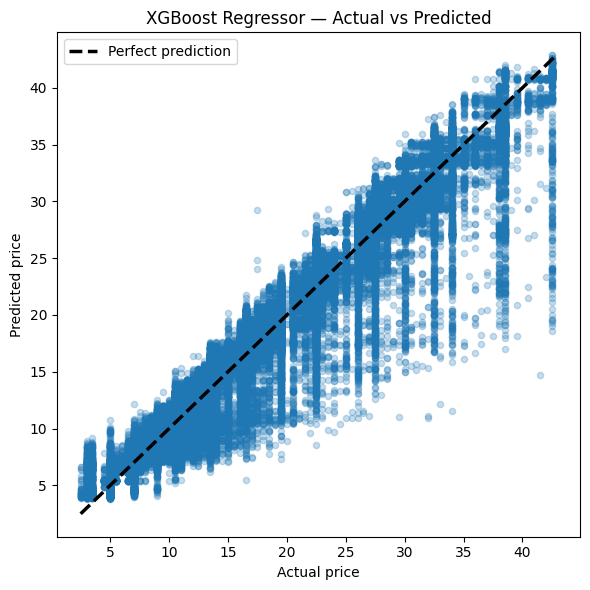

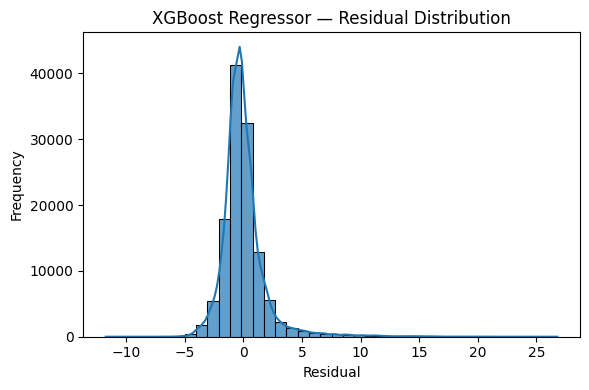

In [47]:
# ============================================================
# Cleaner residual diagnostics with clearer reference lines
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Use the final deployed model (XGBoost pipeline)
final_model_name = "XGBoost Regressor"
final_model = best_xgb

# Predictions
y_true = np.array(y_test).ravel()
y_pred = final_model.predict(X_test).ravel()
residuals = y_true - y_pred

# Choose soft blue for dots, dark line for reference
dot_color = "#1f77b4"
line_color = "black"

# 1) Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.25, color=dot_color, s=20)

# Diagonal reference line
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2.5,
    color=line_color,
    label="Perfect prediction",
)

plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title(f"{final_model_name} — Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Residual histogram
plt.figure(figsize=(6, 4))
sns.histplot(
    residuals,
    bins=40,
    kde=True,
    color=dot_color,
    edgecolor="black",
    alpha=0.7,
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title(f"{final_model_name} — Residual Distribution")
plt.tight_layout()
plt.show()

#### QQ Plot

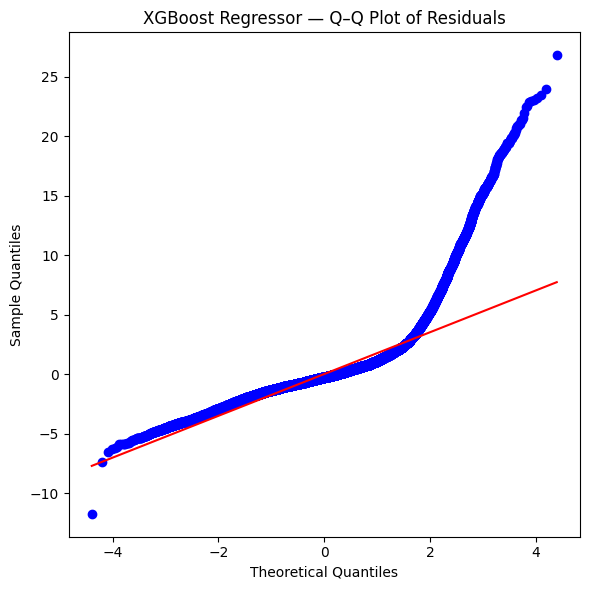

In [48]:
import scipy.stats as stats
import matplotlib.pyplot as plt

# Compute residuals
y_true = np.array(y_test).ravel()
y_pred = final_model.predict(X_test).ravel()
residuals = y_true - y_pred

plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)

plt.title("XGBoost Regressor — Q–Q Plot of Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.tight_layout()
plt.show()

#### Heteroscedasticity Plot

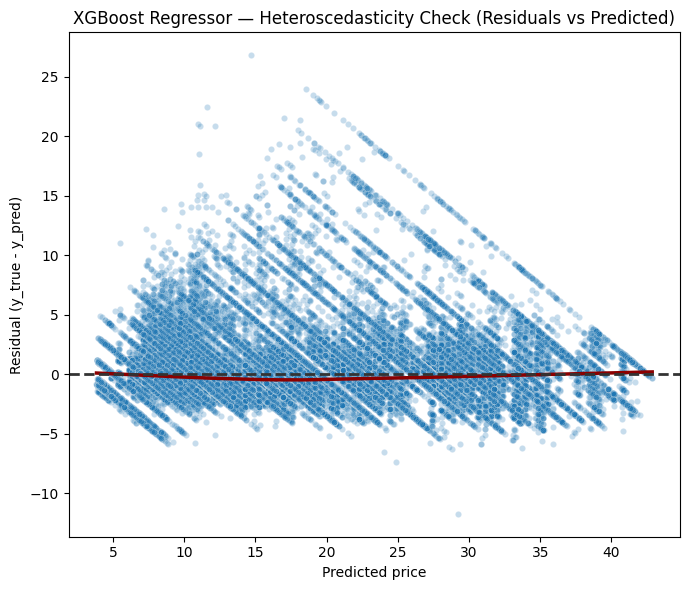

In [49]:
y_true = np.array(y_test).ravel()
y_pred = final_model.predict(X_test).ravel()
residuals = y_true - y_pred

plt.figure(figsize=(7, 6))

# Scatter: residuals vs predictions
sns.scatterplot(x=y_pred, y=residuals, alpha=0.25, s=20, color="#1f77b4")

# LOESS smoothing line (trend)
sns.regplot(
    x=y_pred,
    y=residuals,
    scatter=False,
    lowess=True,
    color="darkred",
    line_kws={"linewidth": 2.5},
)

# Zero reference line
plt.axhline(0, linestyle="--", linewidth=2, color="#333333")

plt.xlabel("Predicted price")
plt.ylabel("Residual (y_true - y_pred)")
plt.title("XGBoost Regressor — Heteroscedasticity Check (Residuals vs Predicted)")
plt.tight_layout()
plt.show()

### Final Feature Importance


Top 20 features for XGBoost Regressor:


,feature,importance
0,cat__name_Lux Black XL,0.344600
1,cat__name_Black SUV,0.258919
2,cat__name_Lux Black,0.101784
3,cat__name_Shared,0.094867
4,cat__name_Lyft,0.046783
5,cat__name_UberPool,0.040938
6,cat__name_WAV,0.036719
7,cat__name_UberX,0.036680
8,cat__name_Lux,0.017976
9,cat__name_UberXL,0.007751


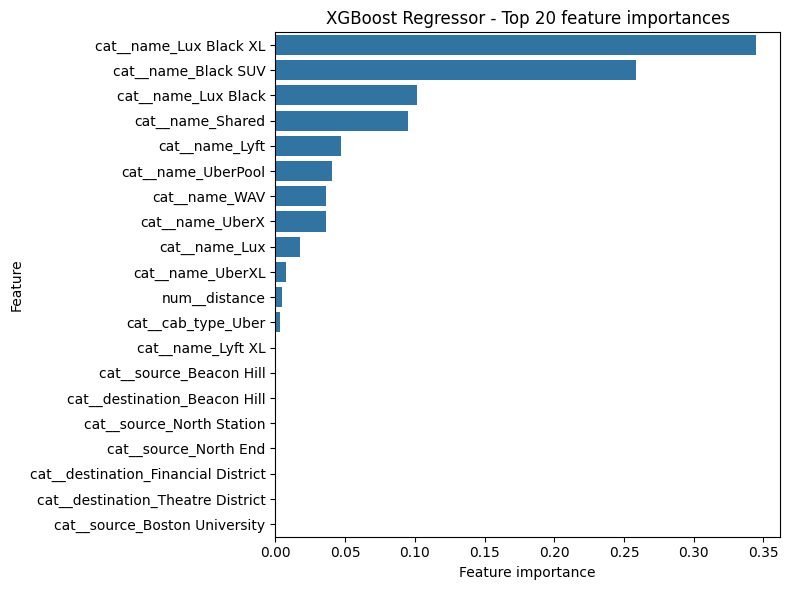

In [50]:
pre = final_model.named_steps["preprocess"]
model = final_model.named_steps["model"]

# Get feature names from the preprocessor
feature_names = pre.get_feature_names_out()

# Get importances from XGBoost
importances = model.feature_importances_

fi_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

# Top k most important features
top_k = 20
fi_top = fi_df.head(top_k)

print(f"\nTop {top_k} features for {final_model_name}:")
display(fi_top)

# Horizontal bar plot for feature importance
plt.figure(figsize=(8, 6))
sns.barplot(
    data=fi_top,
    x="importance",
    y="feature",
    orient="h"
)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title(f"{final_model_name} - Top {top_k} feature importances")
plt.tight_layout()
plt.show()

### Model Deployment

In [51]:
import os
from joblib import dump

# Make sure models folder exists
os.makedirs("../models", exist_ok=True)

# Path to save the final model
model_path = "../models/xgb_best_model.joblib"

# Save the full pipeline (preprocessor + XGBRegressor)
dump(best_xgb, model_path)

print(f"Model saved to: {model_path}")

Model saved to: ../models/xgb_best_model.joblib
